Przetwarzanie strumieni danych lista 9 Oliwia Borkowska

**Zad. 1** Przygotuj kod w Pythonie, które wyznacza wartości następujących miar jakości sygnałów:

SNR = 20 log (s/n)
PSNR = 20 log (s max/ pierw z MSE)
MSE = 1/N * suma(sn - yn)

gdzie: s to sygnał, n to szum, smax to maksymalna wartość sygnału, y to sygnał z zakłóceniem

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, fixed

# Miary jakości: 

# SNR - Signal-to-Noise Ratio
def snr(s, n):
    return 10 * np.log10(np.sum(s ** 2) / np.sum(n ** 2))

# PSNR - Peak Signal-to-Noise Ratio
def psnr(s, y):
    return 10 * np.log10((np.max(np.abs(s)) ** 2) / mse(s, y))

# MSE - Mean Squared Error
def mse(s, y):
    return np.mean((s - y) ** 2)

# dodatkowe:

# NMSE - Normalized Mean Squared Error
def nmse(s, y):
    return np.sum((s - y) ** 2) / np.sum(s ** 2)

# SNR MAX - Max Signal-to-Noise Ratio
def snr_max(s, n):
    return 10 * np.log10((np.max(np.abs(s)) ** 2 * len(s)) / np.sum(n ** 2))

# funkcje sugnałów
def generate_signal(signal_type, t, freq=5, amp=1, freq2=3, amp2=0.5):
    if signal_type == 'Sinus':
        return amp * np.sin(2 * np.pi * freq * t)
    elif signal_type == 'Prostokątny':
        return amp * np.sign(np.sin(2 * np.pi * freq * t))
    elif signal_type == 'Piłokształtny':
        return amp * (2 * (t * freq - np.floor(t * freq + 0.5)))
    elif signal_type == 'Świergotliwy':
        return amp * np.sin(2 * np.pi * (t ** 2) * 30)  # zmienna częstotliwość
    elif signal_type == 'Superpozycja sin + cos':
        return amp * np.sin(2 * np.pi * freq * t) + amp2 * np.cos(2 * np.pi * freq2 * t)
    elif signal_type == 'Impuls jednostkowy':
        s = np.zeros_like(t)
        s[len(t) // 2] = amp
        return s
    else:
        return np.zeros_like(t)

# interaktywna funkcja
def interactive_signal_ui(signal_type, noise_level=0.1, freq=5, amp=1, freq2=3, amp2=0.5):
    t = np.linspace(0, 1, 1000)
    s = generate_signal(signal_type, t, freq, amp, freq2, amp2)
    noise = noise_level * np.random.randn(*s.shape)
    y = s + noise
    n = noise

    plt.figure(figsize=(10, 4))
    plt.plot(t, s, label='Sygnał oryginalny', color = 'magenta')
    plt.plot(t, y, label='Sygnał z zakłóceniem', color = 'pink', alpha=0.7)
    plt.legend()
    plt.title(f'Sygnał: {signal_type}')
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.grid(True)
    plt.show()

    print(f"MSE: {mse(s, y):.5f}")
    print(f"NMSE: {nmse(s, y):.5f}")
    print(f"SNR: {snr(s, n):.2f} dB")
    print(f"SNR_max: {snr_max(s, n):.2f} dB")
    print(f"PSNR: {psnr(s, y):.2f} dB")

# suwaki
interact(
    interactive_signal_ui,
    signal_type=Dropdown(
        options=['Sinus', 'Prostokątny', 'Piłokształtny', 'Świergotliwy', 'Superpozycja sin + cos', 'Impuls jednostkowy'],
        value='Sinus',
        description='Typ sygnału:'
    ),
    noise_level=FloatSlider(value=0.1, min=0, max=1, step=0.01, description='Poziom szumu'),
    freq=FloatSlider(value=5, min=1, max=20, step=1, description='f (Hz)'),
    amp=FloatSlider(value=1, min=0.1, max=2, step=0.1, description='A'),
    freq2=FloatSlider(value=3, min=1, max=20, step=1, description='f2 (Hz)'),
    amp2=FloatSlider(value=0.5, min=0, max=2, step=0.1, description='A2')
)


interactive(children=(Dropdown(description='Typ sygnału:', options=('Sinus', 'Prostokątny', 'Piłokształtny', '…

<function __main__.interactive_signal_ui(signal_type, noise_level=0.1, freq=5, amp=1, freq2=3, amp2=0.5)>

**Zad. 2** Przygotuj kod w Pythonie, który pozwoli na porównanie wartości miar SNR, PSNR, MSE przygotowanych w zadaniu 1 oraz z gotowych implementacji dostępnych w języku Python.

In [40]:
import numpy as np
from scipy import stats

# Z BIBLIOTEKI SCIPY

# MSE
def mse_scipy(s, y):
    return np.mean((s - y) ** 2)

# PSNR
def psnr_scipy(s, y):
    mse_val = mse_scipy(s, y)
    peak = np.max(np.abs(s))
    return 10 * np.log10((peak ** 2) / mse_val)

def snr_scipy(s, n):
    Ps = np.mean(s ** 2)
    Pn = np.mean(n ** 2)
    return 10 * np.log10(Ps / Pn)

# SNR
def snr_stats(y):
    return stats.signaltonoise(y)

def generate_signal_with_noise(length=1000, snr_db=10):
    t = np.linspace(0, 1, length)
    s = np.sin(2 * np.pi * 5 * t)
    np.random.seed(0)
    noise = np.random.randn(length)
    signal_power = np.mean(s ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = noise * np.sqrt(noise_power / np.mean(noise ** 2))
    y = s + noise
    return s, y, noise

s, y, n = generate_signal_with_noise()

print("MSE (scipy/numpy):", mse_scipy(s, y))
print("PSNR (scipy/numpy):", psnr_scipy(s, y))
print("SNR (scipy/numpy):", snr_scipy(s, n))

MSE (scipy/numpy): 0.04995
PSNR (scipy/numpy): 13.014634337124974
SNR (scipy/numpy): 10.0


**Zad. 3** Przygotuj kod w Pythonie, który wygeneruje sygnał świergotliwy z szumem biały oraz szumem browna z zadanym SNR.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

# sygnał świergotliwy (chirp) 
def chirp_signal(t, f0=10, f1=100):
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / 2) * t ** 2))

# szum biały
def generate_white_noise(length):
    return np.random.normal(0, 1, length)

# szum Browna
def generate_brown_noise(length):
    return np.cumsum(np.random.normal(0, 1, length))

# dopasowanie szumu do  SNR 
def scale_noise_to_snr(signal, noise, desired_snr_db):
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    desired_noise_power = signal_power / (10 ** (desired_snr_db / 10))
    scaling_factor = np.sqrt(desired_noise_power / noise_power)
    return noise * scaling_factor

# funkcja interaktywna
def interactive_chirp(snr_db=10, duration=1.0, f0=10, f1=100):
    fs = 1000  # Hz
    t = np.linspace(0, duration, int(fs * duration))
    signal = chirp_signal(t, f0, f1)

    # szum biały
    white_noise = generate_white_noise(len(t))
    white_noise_scaled = scale_noise_to_snr(signal, white_noise, snr_db)
    signal_white = signal + white_noise_scaled

    # szum Browna
    brown_noise = generate_brown_noise(len(t))
    brown_noise_scaled = scale_noise_to_snr(signal, brown_noise, snr_db)
    signal_brown = signal + brown_noise_scaled

    plt.figure(figsize=(14, 6))

    plt.subplot(3, 1, 1)
    plt.plot(t, signal, color='magenta', label='Sygnał świergotliwy (czysty)')
    plt.title(f"Czysty sygnał świergotliwy: f0 = {f0} Hz, f1 = {f1} Hz")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    # szum białym
    plt.subplot(3, 1, 2)
    plt.plot(t, signal_white, color='gray', label='+ szum biały')
    plt.title(f"Chirp + Szum biały (SNR = {snr_db} dB)")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    # szum Browna
    plt.subplot(3, 1, 3)
    plt.plot(t, signal_brown, color='brown', label='+ szum Browna')
    plt.title(f"Chirp + Szum Browna (SNR = {snr_db} dB)")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


# suwaki
interact(
    interactive_chirp,
    snr_db=FloatSlider(value=10, min=0, max=40, step=1, description='SNR [dB]'),
    duration=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description='Czas [s]'),
    f0=IntSlider(value=10, min=1, max=50, step=1, description='f0 (Hz)'),
    f1=IntSlider(value=100, min=10, max=200, step=1, description='f1 (Hz)')
)

interactive(children=(FloatSlider(value=10.0, description='SNR [dB]', max=40.0, step=1.0), FloatSlider(value=1…

<function __main__.interactive_chirp(snr_db=10, duration=1.0, f0=10, f1=100)>

**Zad. 4** Przygotuj kod w Pythonie, który odszumi sygnał z zadania 3 z wykorzystaniem filtru Wienera.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# sygnał świergotliwy
def chirp_signal(t, f0=10, f1=100):
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / 2) * t ** 2))

# szum biały
def white_noise(length):
    return np.random.normal(0, 1, length)

# szum Browna
def brown_noise(length):
    return np.cumsum(np.random.normal(0, 1, length))

# skalowanie do zadanego SNR
def scale_noise(signal, noise, snr_db):
    Ps = np.mean(signal ** 2)
    Pn_desired = Ps / (10 ** (snr_db / 10))
    actual_Pn = np.mean(noise ** 2)
    return noise * np.sqrt(Pn_desired / actual_Pn)

# interaktywna funkcja z filtrem Wienera
def interactive_wiener_filter(snr_db=10, duration=1.0, f0=10, f1=100, noise_type='Biały'):
    fs = 1000  # Hz
    t = np.linspace(0, duration, int(fs * duration))
    clean = chirp_signal(t, f0, f1)

    # wybór szumu
    if noise_type == 'Biały':
        noise = white_noise(len(t))
        color_noise = 'gray'
        label_noise = 'Zaszumiony (biały)'
        title = f"Chirp + Szum biały + filtr Wienera (SNR = {snr_db} dB)"
    else:
        noise = brown_noise(len(t))
        color_noise = 'saddlebrown'
        label_noise = 'Zaszumiony (Browna)'
        title = f"Chirp + Szum Browna + filtr Wienera (SNR = {snr_db} dB)"

    # zakłócony i odszumiony sygnał
    noise_scaled = scale_noise(clean, noise, snr_db)
    noisy_signal = clean + noise_scaled
    denoised_signal = wiener(noisy_signal)

    # wykresy
    plt.figure(figsize=(14, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, clean, color='magenta', label='Czysty sygnał')
    plt.title("Czysty sygnał świergotliwy")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, noisy_signal, color=color_noise, alpha=0.5, label=label_noise)
    plt.plot(t, denoised_signal, color='green', label='Po filtrze Wienera')
    plt.title(title)
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# suwaki interaktywne
interact(
    interactive_wiener_filter,
    snr_db=FloatSlider(value=10, min=0, max=40, step=1, description='SNR [dB]'),
    duration=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description='Czas [s]'),
    f0=IntSlider(value=10, min=1, max=50, step=1, description='f0 (Hz)'),
    f1=IntSlider(value=100, min=10, max=200, step=1, description='f1 (Hz)'),
    noise_type=Dropdown(options=['Biały', 'Browna'], description='Typ szumu')
)

interactive(children=(FloatSlider(value=10.0, description='SNR [dB]', max=40.0, step=1.0), FloatSlider(value=1…

<function __main__.interactive_wiener_filter(snr_db=10, duration=1.0, f0=10, f1=100, noise_type='Biały')>

**Zad. 5** Przygotuj kod w Pythonie, który odszumi sygnał z zadania 3 z wykorzystaniem filtru Savitzkyego-Golaya.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider

# sygnał świergotliwy
def chirp_signal(t, f0=10, f1=100):
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / 2) * t ** 2))

# szum biały
def generate_white_noise(length):
    return np.random.normal(0, 1, length)

# szum Browna
def generate_brown_noise(length):
    return np.cumsum(np.random.normal(0, 1, length))

# dopasowanie szumu do SNR
def scale_noise_to_snr(signal, noise, desired_snr_db):
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    desired_noise_power = signal_power / (10 ** (desired_snr_db / 10))
    scaling_factor = np.sqrt(desired_noise_power / noise_power)
    return noise * scaling_factor

# interaktywna funkcja
def interactive_denoise_chirp(snr_db=10, duration=1.0, f0=10, f1=100, window_length=51, polyorder=3): # polyorder - rządwielomianu,mniejszy niż window_length, wyższy = mniej wygładzania
    fs = 1000  # Hz
    t = np.linspace(0, duration, int(fs * duration))
    signal = chirp_signal(t, f0, f1)

    # dodanie szumu
    white_noise = generate_white_noise(len(t))
    white_noise_scaled = scale_noise_to_snr(signal, white_noise, snr_db)
    signal_white = signal + white_noise_scaled

    brown_noise = generate_brown_noise(len(t))
    brown_noise_scaled = scale_noise_to_snr(signal, brown_noise, snr_db)
    signal_brown = signal + brown_noise_scaled

    # filtracja Savitzky-Golaya
    if window_length % 2 == 0:
        window_length += 1  # okno musi być nieparzyste

    denoised_white = savgol_filter(signal_white, window_length, polyorder)
    denoised_brown = savgol_filter(signal_brown, window_length, polyorder)

    plt.figure(figsize=(14, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, signal, color='magenta', label='Czysty sygnał')
    plt.title("Czysty sygnał świergotliwy")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(t, signal_white, color='gray', alpha=0.5, label='Zaszumiony (biały)')
    plt.plot(t, denoised_white, color='blue', label='Po filtrze SG')
    plt.title(f"Chirp + Szum biały + filtr SG (SNR = {snr_db} dB)")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(t, signal_brown, color='brown', alpha=0.5, label='Zaszumiony (Brown)')
    plt.plot(t, denoised_brown, color='green', label='Po filtrze SG')
    plt.title(f"Chirp + Szum Browna + filtr SG (SNR = {snr_db} dB)")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# interaktywne suwaki
interact(
    interactive_denoise_chirp,
    snr_db=FloatSlider(value=10, min=0, max=40, step=1, description='SNR [dB]'),
    duration=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description='Czas [s]'),
    f0=IntSlider(value=10, min=1, max=50, step=1, description='f0 (Hz)'),
    f1=IntSlider(value=100, min=10, max=200, step=1, description='f1 (Hz)'),
    window_length=IntSlider(value=51, min=5, max=201, step=2, description='Okno SG'),
    polyorder=IntSlider(value=3, min=1, max=5, step=1, description='Stopień SG')
)

interactive(children=(FloatSlider(value=10.0, description='SNR [dB]', max=40.0, step=1.0), FloatSlider(value=1…

<function __main__.interactive_denoise_chirp(snr_db=10, duration=1.0, f0=10, f1=100, window_length=51, polyorder=3)>

**Zad. 6** Przygotuj kod w Pythonie, który odszumi sygnał z zadania 3 z wykorzystaniem filtru bazującego na algorytmie EMD i częściowej rekonstrukcji.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
from PyEMD import EMD

# sygnał świergotliwy
def chirp_signal(t, f0=10, f1=100):
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / 2) * t ** 2))

# szum biały
def white_noise(length):
    return np.random.normal(0, 1, length)

# szum Browna
def brown_noise(length):
    return np.cumsum(np.random.normal(0, 1, length))

# dopasowanie szumu do zadanego SNR
def scale_noise(signal, noise, snr_db):
    Ps = np.mean(signal ** 2)
    Pn_desired = Ps / (10 ** (snr_db / 10))
    actual_Pn = np.mean(noise ** 2)
    return noise * np.sqrt(Pn_desired / actual_Pn)

# interaktywna funkcja z filtrem EMD
def interactive_emd_filter(snr_db=10, duration=1.0, f0=10, f1=100, noise_type='Biały', imf_limit=3):
    fs = 1000
    t = np.linspace(0, duration, int(fs * duration))
    clean = chirp_signal(t, f0, f1)

    # wybór szumu
    if noise_type == 'Biały':
        noise = white_noise(len(t))
        color_noise = 'gray'
        label_noise = 'Zaszumiony (biały)'
        title = f"Chirp + Szum biały + EMD (SNR = {snr_db} dB)"
    else:
        noise = brown_noise(len(t))
        color_noise = 'saddlebrown'
        label_noise = 'Zaszumiony (Browna)'
        title = f"Chirp + Szum Browna + EMD (SNR = {snr_db} dB)"

    noisy_signal = clean + scale_noise(clean, noise, snr_db)

    # EMD
    emd = EMD()
    imfs = emd.emd(noisy_signal)

    # ograniczenie liczby IMF do rekonstrukcji
    imf_count = min(imf_limit, imfs.shape[0])
    reconstructed = np.sum(imfs[:imf_count], axis=0)

    plt.figure(figsize=(14, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, clean, color='magenta', label='Czysty sygnał')
    plt.title("Czysty sygnał świergotliwy")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, noisy_signal, color=color_noise, alpha=0.5, label=label_noise)
    plt.plot(t, reconstructed, color='green', label=f'Po EMD (IMF 1–{imf_count})')
    plt.title(title)
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# suwaki
interact(
    interactive_emd_filter,
    snr_db=FloatSlider(value=10, min=0, max=40, step=1, description='SNR [dB]'),
    duration=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description='Czas [s]'),
    f0=IntSlider(value=10, min=1, max=50, step=1, description='f0 (Hz)'),
    f1=IntSlider(value=100, min=10, max=200, step=1, description='f1 (Hz)'),
    noise_type=Dropdown(options=['Biały', 'Browna'], description='Typ szumu'),
    imf_limit=IntSlider(value=3, min=1, max=10, step=1, description='IMFs')
)

interactive(children=(FloatSlider(value=10.0, description='SNR [dB]', max=40.0, step=1.0), FloatSlider(value=1…

<function __main__.interactive_emd_filter(snr_db=10, duration=1.0, f0=10, f1=100, noise_type='Biały', imf_limit=3)>

**Zad. 7** Przygotuj kod w Pythonie, który odszumi sygnał załadowany z pliku csv oraz odszumi ten sygnał wykorzystując filtr Wienera, Savitzkyego-Golaya oraz bazującego na algorytmie EMD i częściowej rekonstrukcji.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, wiener
from scipy import signal
from PyEMD import EMD

# wygenerowanie sygnału piłokształtnego z szumem białym i zapisanie go jako csv

fs = 1000
duration = 2.0
t = np.linspace(0, duration, int(fs * duration))
clean_signal = signal.sawtooth(2 * np.pi * 5 * t)  # piłokształtny 5 Hz

# szum biały o zadanym SNR
snr_db = 10
white_noise = np.random.normal(0, 1, len(t))
signal_power = np.mean(clean_signal ** 2)
noise_power = np.mean(white_noise ** 2)
scale = np.sqrt(signal_power / (10 ** (snr_db / 10)) / noise_power)
noisy_signal = clean_signal + white_noise * scale

# zapis do CSV (dwie kolumny: t i sygnał)
data = np.column_stack((t, noisy_signal))
np.savetxt("sygnal_zaszumiony.csv", data, delimiter=",", header="time,noisy_signal", comments='')
print("Zapisano plik sygnal_zaszumiony.csv")


Zapisano plik sygnal_zaszumiony.csv


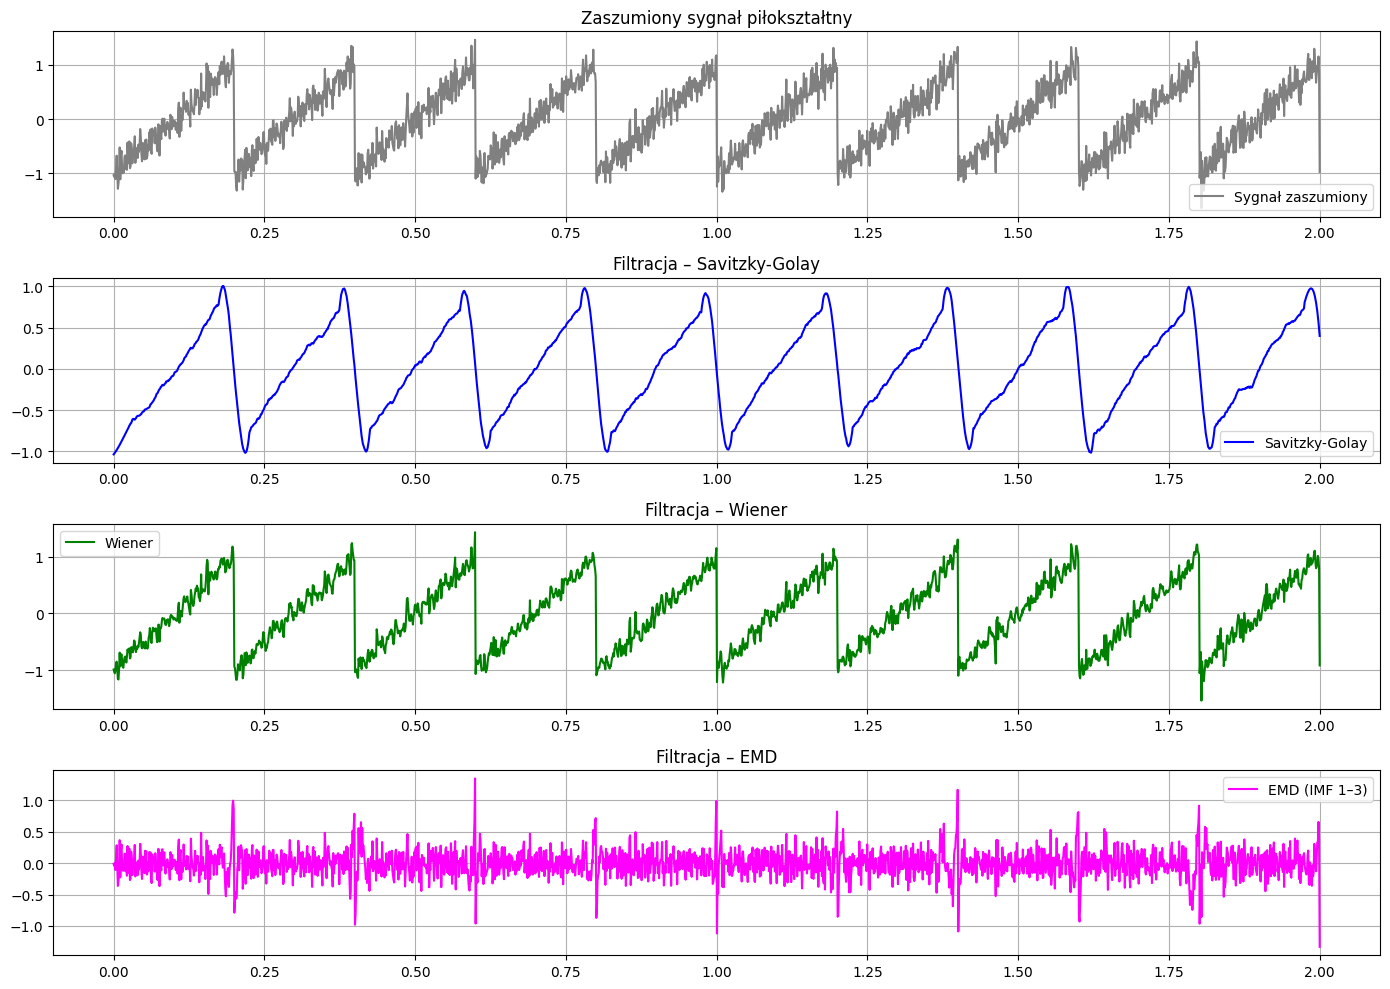

In [31]:
# wczytanie danych

loaded_data = np.loadtxt("sygnal_zaszumiony.csv", delimiter=",", skiprows=1)
t = loaded_data[:, 0]
noisy_signal = loaded_data[:, 1]

# filtracja

# Filtr Savitzky-Golaya
sg_filtered = savgol_filter(noisy_signal, window_length=51, polyorder=3)

# Filtr Wienera
wiener_filtered = wiener(noisy_signal)

# Filtr EMD (częściowa rekonstrukcja)
emd = EMD()
imfs = emd.emd(noisy_signal)
reconstructed_emd = np.sum(imfs[:3], axis=0)  # np. 3 pierwsze składowe

# wykresy
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t, noisy_signal, color='gray', label='Sygnał zaszumiony')
plt.title('Zaszumiony sygnał piłokształtny')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t, sg_filtered, color='blue', label='Savitzky-Golay')
plt.title('Filtracja – Savitzky-Golay')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t, wiener_filtered, color='green', label='Wiener')
plt.title('Filtracja – Wiener')
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(t, reconstructed_emd, color='magenta', label='EMD (IMF 1–3)')
plt.title('Filtracja – EMD')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()